# Inverse UQ example: Shocktube

In [169]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import umbridge as um
from matplotlib.animation import FuncAnimation
from Riemann import RiemannProblem

from scipy.integrate import solve_ivp

import tinyDA as tda

In [170]:
np.random.seed(42)

We implement two slightly incompatible models. `UmbridgeArepoModel` obeys the UM-Bridge interface, and `NpArepoModel` is a wrapper that is compatible with tinyDA.

In [171]:
class UmbridgeArepoModel(um.Model):
    def __init__(self):
        super().__init__("forward")

    def get_input_sizes(self, config):
        return [4]
    
    def get_output_sizes(self, config):
        return [4]
    
    def __call__(self, parameters, config={}):
        RESOLUTION = 200
        input = parameters[0]
        rho_L, v_L, p_L = input[0]
        rho_R, v_R, p_R = input[1]
        T_max, n_T = input[2]
        L_max, n_L = input[3]

        time = np.linspace(0, T_max, n_T + 1)
        solutions = [
            RiemannProblem(np.linspace(0, L_max, RESOLUTION), L_max / 2.0, [p_L, v_L, rho_L], [p_R, v_R, rho_R], 1.4, t)[1]
            for t in time
        ]

        def convert_space_index(input):
            return int(input * (RESOLUTION - 1) / n_L)

        return [
            [
                [], # x coordinates
                [
                    [
                        solutions[t][convert_space_index(s), 0] # 0 = density
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ],
                [
                    [
                        solutions[t][convert_space_index(s), 1] # 1 = velocity
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ],
                [
                    [
                        solutions[t][convert_space_index(s), 2] # 2 = pressure
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ]
            ]
        ]

    def supports_evaluate(self):
        return True
    
class NpArepoModel(um.Model):
    def __init__(self, inner_model, n_L=5, n_T=20, L_max=20, T_max=20):
        self.inner = inner_model
        self.n_L = n_L
        self.n_T = n_T
        self.L_max = L_max
        self.T_max = T_max

    def __call__(self, parameters):
        left = [0, 0, 0]
        right = [0, 0, 0]
        left[0] = parameters[0]
        left[1] = 0.0
        left[2] = parameters[1]
        right[0] = parameters[2]
        right[1] = 0.0
        right[2] = parameters[3]
        return np.array(self.inner([[left, right, [self.T_max, self.n_T], [self.L_max, self.n_L]]])[0][3]).flatten(), True

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0

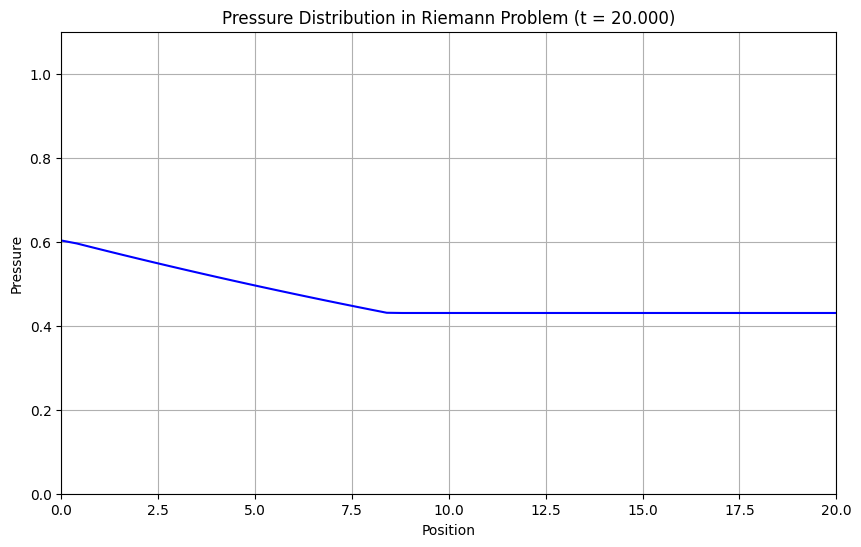

In [172]:
test_model = UmbridgeArepoModel()

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot([], [], 'b-')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.1)  # Adjust as needed
ax.set_title('Pressure Distribution in Riemann Problem')
ax.set_xlabel('Position')
ax.set_ylabel('Pressure')
ax.grid(True)

L_max = T_max = 20
n_L = 50
n_T = 20

results = test_model([[[1.0, 0.0, 1.0], [0.125, 0.0, 0.1], [T_max, n_T], [L_max, n_L]]])[0]

# Animation update function
def update(frame):
    t = frame
    pressure = results[1][t]
    print(pressure)
    line.set_data(np.linspace(0, L_max, n_L + 1), pressure)
    ax.set_title(f'Pressure Distribution in Riemann Problem (t = {t:.3f})')
    return line,

# Create the animation
anim = FuncAnimation(fig, update, frames=21, interval=50, blit=True)

# Display the animation
from IPython.display import HTML
HTML(anim.to_jshtml())

### Set up the true model

In [173]:
# set the true parameters. Our (noisy) measurements are based on these.
rho_L = 1.0 # initial density of the left half
p_L = 1.0 # initial pressure of the left half
rho_R = 0.125 # initial density of the right half
p_R = 0.1 # initial pressure of the right half
T_max = 20
n_T = 20
L_max = 20
n_L = 5

# collect the parameters in a vector. 
# we sample the log of the parameters and take the exponential
# inside the model to keep the parameters positive.
true_parameters = np.array([rho_L, p_L, rho_R, p_R])

my_exact_model = NpArepoModel(UmbridgeArepoModel(), n_L=n_L, n_T=n_T, L_max=L_max, T_max=T_max)

# initalise the true model and solve it
my_model = NpArepoModel(UmbridgeArepoModel(), n_L=n_L, n_T=n_T, L_max=L_max, T_max=T_max)
y_true = my_model(true_parameters)[0]
print(y_true)

[1.         1.         1.         0.125      0.125      0.125
 1.         1.         1.         0.30713447 0.125      0.125
 1.         1.         0.85849441 0.30713447 0.125      0.125
 1.         1.         0.60202114 0.30713447 0.125      0.125
 1.         1.         0.50062904 0.30713447 0.30713447 0.125
 1.         1.         0.44712166 0.30713447 0.30713447 0.125
 1.         0.84410737 0.41424077 0.30713447 0.30713447 0.30713447
 1.         0.72813438 0.39204356 0.30713447 0.30713447 0.30713447
 1.         0.65037918 0.37607212 0.30713447 0.30713447 0.30713447
 0.93103366 0.59493009 0.36403858 0.30713447 0.30713447 0.30713447
 0.83274702 0.55353706 0.35465084 0.30713447 0.30713447 0.30713447
 0.75908034 0.52153046 0.34712505 0.30713447 0.30713447 0.30713447
 0.70202924 0.49608309 0.34095853 0.30713447 0.30713447 0.30713447
 0.65666554 0.47538937 0.33581428 0.30713447 0.30713447 0.30713447
 0.61980548 0.4582452  0.33145802 0.30713447 0.30713447 0.30713447
 0.58930892 0.44381832 0.

### Set up the forward models

In [174]:
# n_data = 25 # number of datapoints
# t_eval_data = np.linspace(t_span[0], t_span[1], n_data) # datapoints

# # fine model
# my_fine_model = PredatorPreyModel(t_eval_data, method='Radau') # initialise model

# # coarse model
# my_coarse_model = PredatorPreyModel(t_eval_data, method='RK45') # initialise model

### Generate data

In [175]:
# set the noise level
sigma = 1.0


experimental_measurements = np.array(my_exact_model(true_parameters)[0])

noise = np.random.normal(scale=sigma, size=experimental_measurements.size) # fine noise
data = experimental_measurements + noise # noisy fine data.
data[data < 0] = 0 # make sure all the data is positive.

### Plot the true model and the data

In [176]:
# y_coarse = PredatorPreyModel(t_eval, method='RK45')(true_parameters)[0]
# fig, axes = plt.subplots(figsize=(16,5), nrows=1, ncols=2)

# axes[0].set_title('Prey', fontsize=12)
# axes[0].plot(t_eval, y_true[:n_eval], '--', color='cornflowerblue')
# axes[0].plot(t_eval, y_coarse[:n_eval], '--', color='limegreen')
# axes[0].scatter(t_eval_data, data[:n_data], color='tomato')
# axes[0].tick_params(axis='both', labelsize=12)
# axes[0].set_xlabel('Time', fontsize=12)
# axes[0].set_ylim(0, 14); axes[0].set_ylabel('Density', fontsize=12)
# #axes[0].legend(loc=2, fontsize=12)

# axes[1].set_title('Predators', fontsize=12)
# axes[1].plot(t_eval, y_true[n_eval:], '--', color='cornflowerblue', label='Fine model')
# axes[1].plot(t_eval, y_coarse[n_eval:], '--', color='limegreen', label='Coarse model')
# axes[1].scatter(t_eval_data, data[n_data:], color='tomato', label='Noisy data')
# axes[1].tick_params(axis='both', labelsize=12)
# axes[1].set_xlabel('Time', fontsize=12)
# axes[1].set_ylim(0, 14); axes[1].set_ylabel('Density', fontsize=12)
# axes[1].legend(loc=1, fontsize=12)

# plt.show()

### Set up the statistical model  and draw some samples from the prior
We need a fairly well-informed prior, since the model is nonlinear and the data is quite noisy. Hence, we assume that we have pretty good knowledge about the birth- and death rates of the prey and predators, respectively. The predation rate and the growth rate for the predators are left to be fairly uncertain.

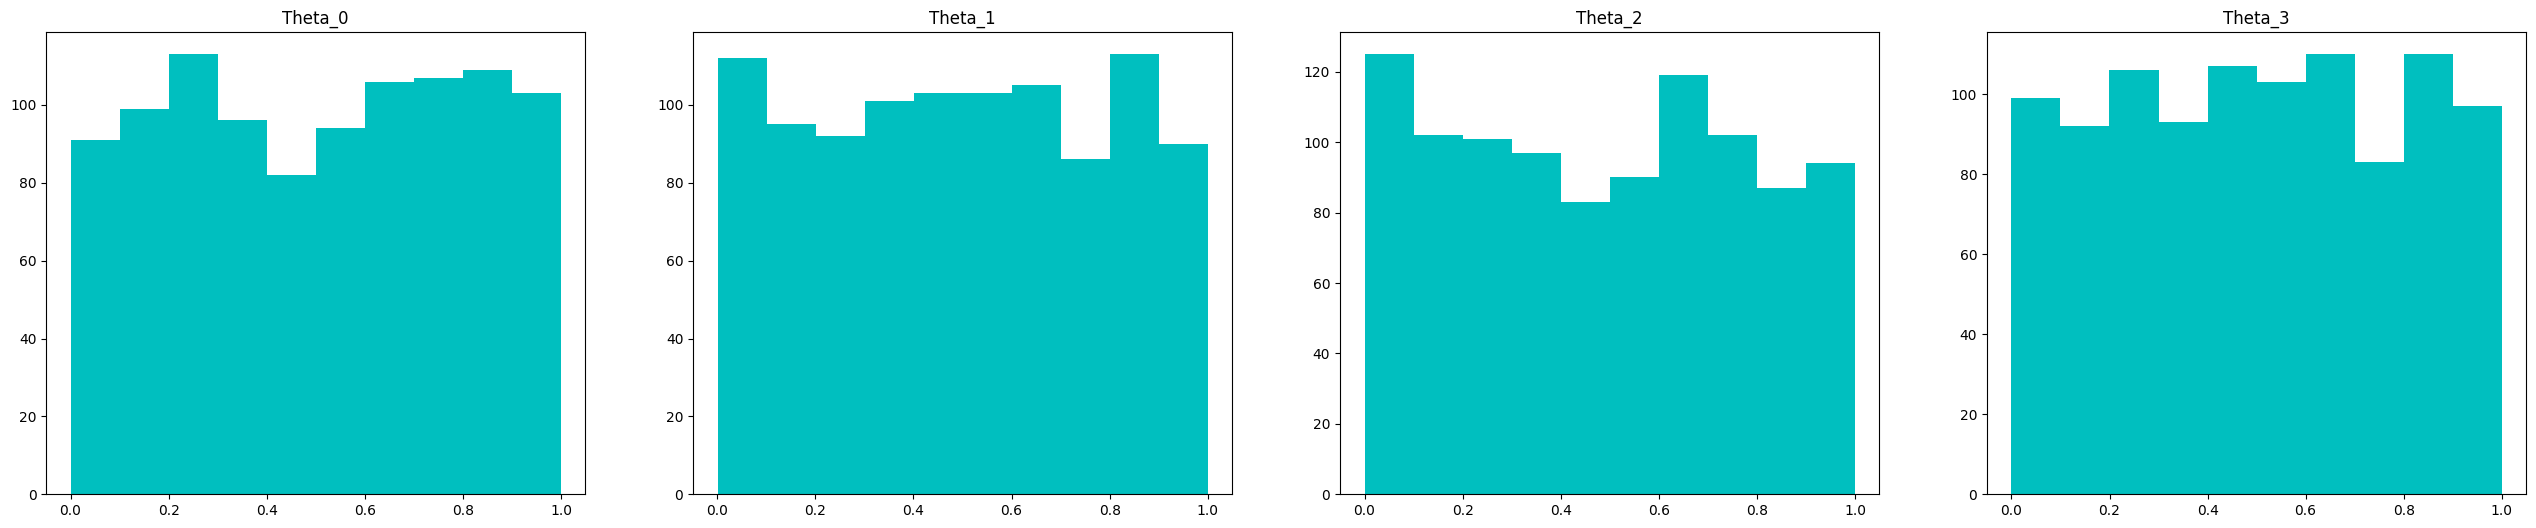

In [177]:
# prior distribution
# mean_prior = np.array([0.0, 0.0])
# cov_prior = np.diag([1.0, 1.0])
# my_prior = stats.multivariate_normal(mean_prior, cov_prior)
# low = [0, 0]
# high = [1, 1]
# my_prior = stats.uniform(loc=low, scale=high)
class MultivariatePrior:
    def __init__(self, low, high):
        self.low = np.array(low)
        self.high = np.array(high)
        self.dim = len(low)

    def logpdf(self, x):
        x = np.array(x)
        in_range = np.all((x >= self.low) & (x <= self.high))
        return 0 if in_range else -np.inf  # np.where(in_range, 0, -np.inf)

    def rvs(self, size=1):
        if isinstance(size, int):
            size = (size, self.dim)
        elif isinstance(size, tuple) and len(size) == 1:
            size = size + (self.dim,)
        samples = np.random.uniform(self.low, self.high, size=size)
        if size == 1 or (isinstance(size, tuple) and size[0] == 1):
            return samples[0]
        return samples

# Set up the prior
low = np.array([0, 0, 0, 0])
high = np.array([1, 1, 1, 1])
my_prior = MultivariatePrior(low, high)

# draw some samples and plot them
prior_samples = my_prior.rvs(size=(1000, 4))
fig, axes = plt.subplots(nrows=1, ncols=4, figsize = (8*4, 6))
for i in range(4):
    axes[i].set_title('Theta_{}'.format(i))
    axes[i].hist(prior_samples[:,i], color='c')

In [178]:
# define the likelihood
cov_likelihood = sigma**2*np.eye(data.size)

my_loglike = tda.GaussianLogLike(data, cov_likelihood)

### Set up the link factories and get the MAP point

In [179]:
# set up the link factories
my_posterior = tda.Posterior(my_prior, my_loglike, my_model)

my_posteriors = [my_posterior]

my_posterior.prior.rvs()

array([0.60713528, 0.38872635, 0.24029912, 0.09496528])

In [180]:
# get the maximum a posteriori point.
MAP = tda.get_MAP(my_posterior)
MAP

/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:111: RuntimeWarning: invalid value encountered in sqrt
  a_L = np.sqrt( gamma *  W_L[2] / W_L[0] )    ## sound speeds
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:20: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt(  gamma * W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:40: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt( gamma_K *  W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:79: RuntimeWarning: invalid value encountered in sqrt
  a = np.sqrt( gamma * W_K[2] / W_K[0] )
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(

array([0.75162263, 0.16938267, 0.35314404, 0.5067699 ])

### Set up the proposal

In [181]:
# random walk Metropolis
#rwmh_cov = np.eye(2)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Niconson
#pcn_scaling = 0.1
#pcn_adaptive = True
#my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# Adaptive Metropolis
am_cov = np.eye(true_parameters.size)
am_t0 = 100
am_sd = None
am_epsilon = 1e-6
am_adaptive = True
my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

### Sample

In [182]:
import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 120
    burnin = 20

In [183]:
# initialise the chain
my_chain = tda.sample(my_posteriors, my_proposal, iterations=iterations, n_chains=2, initial_parameters=MAP, subchain_length=5, adaptive_error_model='state-independent', force_sequential=True)

Sampling chain 1/2
[0.75162263 0.16938267 0.35314404 0.5067699 ]


Running chain, α = 1.00:   0%|          | 0/120 [00:00<?, ?it/s]/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:25: RuntimeWarning: invalid value encountered in sqrt
  return ( pres - W_K[2] ) * np.sqrt( A / ( pres + B ) )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:45: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt( A / ( B + pres ) ) * ( 1.0 - ( pres - W_K[2] ) / ( 2.0 * ( B + pres ) ) )
Running chain, α = 0.50:   0%|          | 0/120 [00:00<?, ?it/s]/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:112: RuntimeWarning: invalid value encountered in sqrt
  a_R = np.sqrt( gamma *  W_R[2] / W_R[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:20: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt(  gamma * W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:40: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt( gamma_K *  W_K[2] / W_K[0] )
/ho

Sampling chain 2/2
[0.75162263 0.16938267 0.35314404 0.5067699 ]


Running chain, α = 0.19: 100%|██████████| 120/120 [00:00<00:00, 162.32it/s]


### Diagnostics

In [184]:
print(my_chain['chain_0'][0].prior)
idata = tda.to_inference_data(my_chain, level='fine', burnin=burnin)

0


/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [185]:
import arviz as az

In [186]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,0.744,0.024,0.687,0.756,0.009,0.006,16.0,5.0,1.80
x1,0.179,0.027,0.169,0.242,0.010,0.008,17.0,5.0,1.78
x2,0.362,0.027,0.350,0.426,0.010,0.008,18.0,19.0,1.79
x3,0.489,0.056,0.357,0.515,0.020,0.015,21.0,6.0,1.81


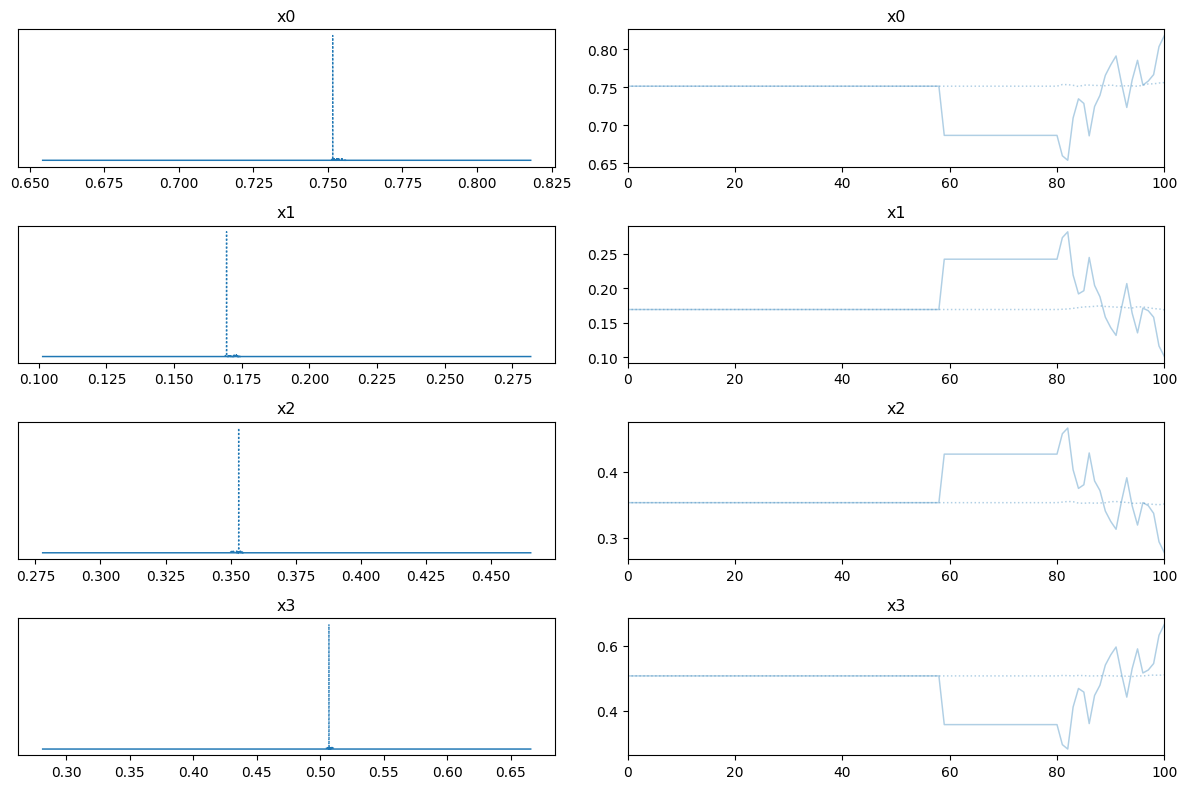

In [187]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

In [188]:
rv = stats.uniform(loc=np.array([0, 0]), scale=(np.array([1, 1])))
rv.rvs(size=(10, 2))

array([[0.75664655, 0.58243508],
       [0.1865901 , 0.1882322 ],
       [0.18424865, 0.05700239],
       [0.58779845, 0.84034818],
       [0.01749821, 0.04900464],
       [0.57277028, 0.81949569],
       [0.32673889, 0.3496144 ],
       [0.5963465 , 0.27421289],
       [0.02660837, 0.73522852],
       [0.62564991, 0.580756  ]])